In [23]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model="openai/gpt-oss-20b")

In [6]:
class ChatbotState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]
    

In [7]:
def Chatbot(state:ChatbotState)->ChatbotState:
    message = state["messages"]
    response = model.invoke(message)
    return {"messages":[response]}

In [24]:
checkpointer = MemorySaver()
graph = StateGraph(ChatbotState)
graph.add_node("Chatbot",Chatbot)

In [25]:
graph.add_edge(START,"Chatbot")
graph.add_edge("Chatbot",END)
workflow = graph.compile(checkpointer=checkpointer)

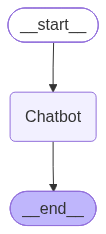

In [26]:
workflow

In [28]:
thread_id = '1'
initial_state = {
    'messages':[HumanMessage(content="what is the science behind tyres")]
}
config = {'configurable':{'thread_id':thread_id}}
result = workflow.invoke(initial_state,config=config)

In [15]:
result

{'messages': [HumanMessage(content='what is the science behind tyres', additional_kwargs={}, response_metadata={}, id='f0da5b5c-1954-4f74-b05c-b8c408131afd'),
  AIMessage(content='## The Science of Tyres – From Rubber to Road\n\nA tyre is a marvel of engineering that turns the static load of a vehicle into a dynamic, controllable interaction with the road. At its heart it’s a composite structure that must satisfy many competing requirements: grip, durability, fuel‑efficiency, safety, and comfort. Below is a “behind‑the‑scenes” look at the science that makes it all possible.\n\n---\n\n### 1. The Basic Architecture\n\n| Layer | Purpose | Key Materials | Typical Thickness |\n|-------|---------|---------------|-------------------|\n| **Tread** | Contact with road, grip, water‑shedding | Rubber‑silica blend, carbon‑black | 5–10\u202fmm |\n| **Sidewall** | Flexibility, vibration isolation | Similar rubber blend | 3–8\u202fmm |\n| **Belt (or ply)** | Structural strength, load‑carrying | Steel

In [29]:
while True:
    user = input("Type here:")
    print("user:"+user)
    if user.strip().lower() in ["exit","stop","end","bye"]:
        break
    response = workflow.invoke({"messages":[HumanMessage(content=user)]},config=config)
    print("AI:",response['messages'][-1].content)

user:hello
AI: Hello! How can I help you today?
user:how was your day
AI: I’m just a bundle of code, so I don’t have days in the human sense—no coffee breaks or traffic jams! But I’m here and ready to help you out. How’s your day going?
user:what is 120 - 3
AI: 120 – 3 = **117**
user:add 40 to the result
AI: 117 + 40 = **157**
user:good 
AI: Glad to hear it! Anything else you’d like to calculate or chat about?
user:bye
